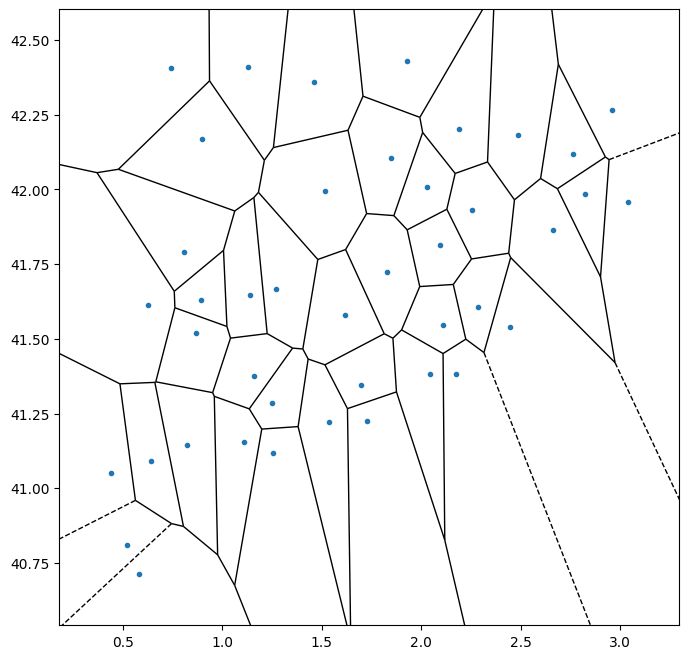

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import Voronoi, voronoi_plot_2d

num_points = 10
seed = 0
df = pd.read_csv("capitals_comarca.csv")
points = df[["Longitud", "Latitud"]].values
voronoi = Voronoi(points)
fig, ax = plt.subplots(figsize=(8, 8))
voronoi_plot_2d(voronoi, ax=ax, show_vertices=False, line_colors='black')

plt.show()


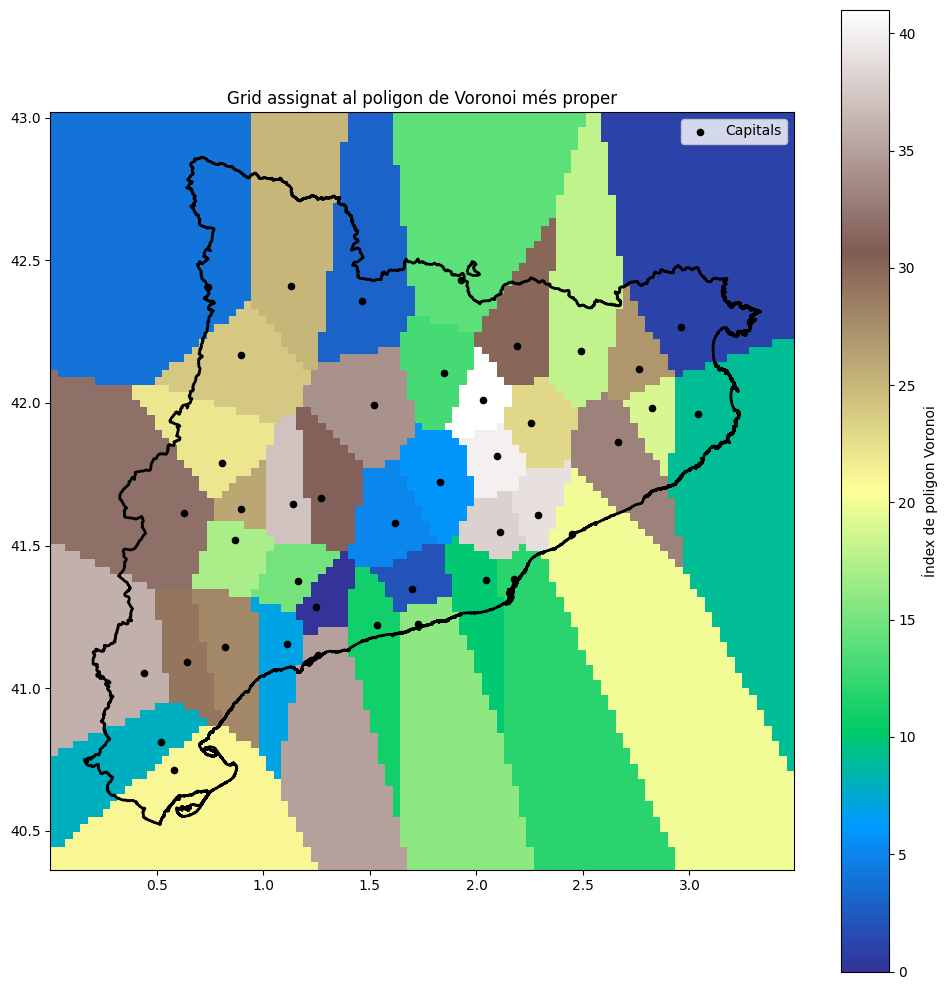

Exemple de matriu de noms de regió de cel·la:
<StringArray>
[
['Amposta', 'Amposta', 'Amposta', 'Amposta', 'Amposta'],
['Amposta', 'Amposta', 'Amposta', 'Amposta', 'Amposta'],
['Amposta', 'Amposta', 'Amposta', 'Amposta', 'Amposta'],
['Tortosa', 'Tortosa', 'Amposta', 'Amposta', 'Amposta'],
['Tortosa', 'Tortosa', 'Tortosa', 'Amposta', 'Amposta']
]
Shape: (5, 5), dtype: str


In [92]:
import geopandas as gpd
# -------------------------
# 1. GRID ABM
# -------------------------

nx, ny = 100, 100
gdf = gpd.read_file("divisions-administratives-v2r2-catalunya-5000-20260120.json")
# Crear un grid regular sobre l'extensió dels punts de capitals
xmin, ymin, xmax, ymax = gdf.total_bounds
padding = 0.05 * max(xmax - xmin, ymax - ymin)
xmin -= padding
xmax += padding
ymin -= padding
ymax += padding

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
xx, yy = np.meshgrid(x_centers, y_centers)
cell_centers = np.column_stack([xx.ravel(), yy.ravel()])

from scipy.spatial import cKDTree
kdtree = cKDTree(points)
cell_region_index = kdtree.query(cell_centers, k=1)[1].reshape(ny, nx)

fig, ax = plt.subplots(figsize=(10, 10))
mesh = ax.pcolormesh(
    x_edges,
    y_edges,
    cell_region_index,
    cmap="terrain",
    shading="auto",
)
ax.scatter(points[:, 0], points[:, 1], color='black', s=20, label='Capitals')
ax.set_title('Grid assignat al poligon de Voronoi més proper')
gdf.boundary.plot(ax=ax, color="black", linewidth=2)
plt.colorbar(mesh, ax=ax, label='Índex de poligon Voronoi')
plt.legend()
plt.tight_layout()
plt.show()

region_names = df['Municipi'].values
cell_region_name = region_names[cell_region_index]
print('Exemple de matriu de noms de regió de cel·la:')
print(cell_region_name[:5, :5])

In [78]:
import numpy as np
from shapely.geometry import Point
from shapely.ops import unary_union


# Reparar geometries invalides abans de fer la unió
safe_geoms = [geom.buffer(0) if geom is not None and not geom.is_valid else geom for geom in gdf.geometry]
gdf = gdf.set_geometry(safe_geoms)
gdf = gdf[gdf.geometry.notna()].copy()

# Excloure les cel·les del grid que queden fora del polígon de Catalunya
poly = unary_union(gdf.geometry)
cell_inside = np.array([poly.covers(Point(x, y)) for x, y in cell_centers]).reshape(ny, nx)

# Generar mask
mask = np.ones((ny, nx))

# Marcar com a NaN els valors fora del polígon i actualitzar la regió
mask = np.where(cell_inside, mask, np.nan)
cell_region_index = np.where(cell_inside, cell_region_index, -1)
cell_region_name = np.where(cell_inside, cell_region_name, "")

print('Cel·les dins del polígon:', cell_inside.sum())
print('Cel·les fora del polígon:', np.size(cell_inside) - cell_inside.sum())

Cel·les dins del polígon: 3754
Cel·les fora del polígon: 6246


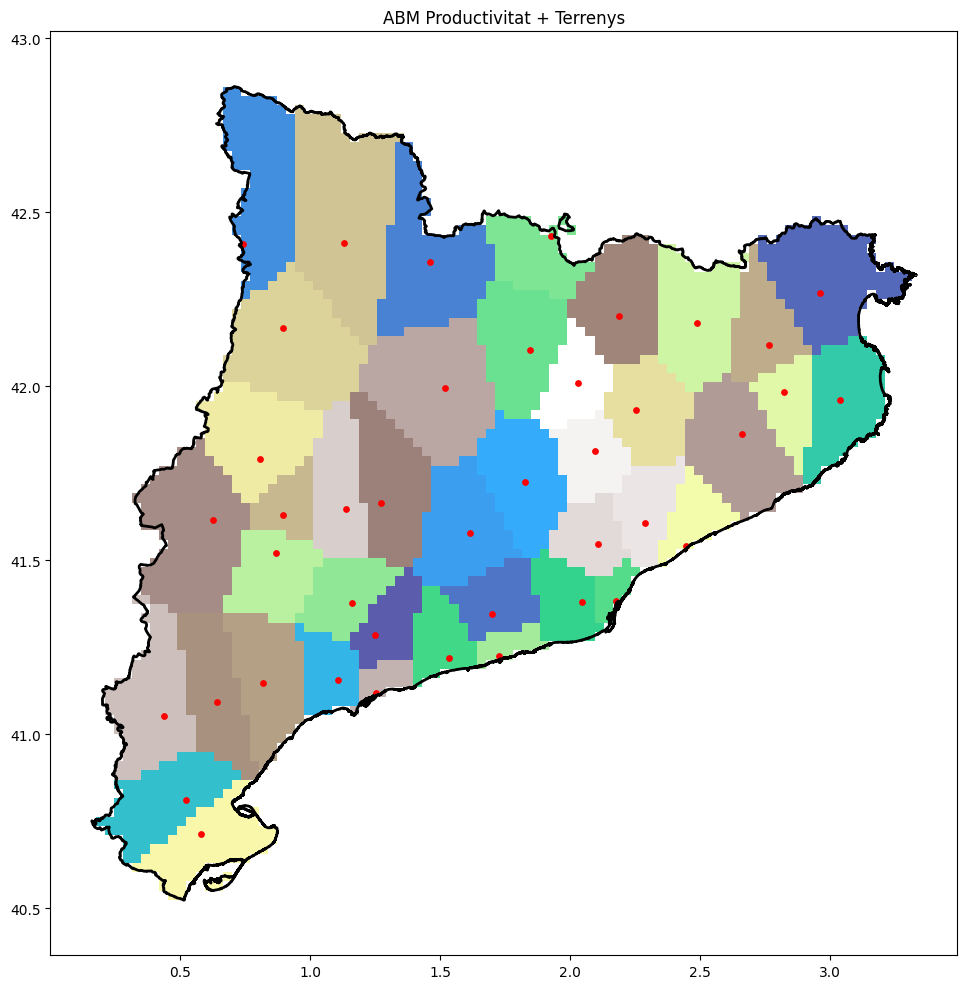

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Polygon



# -------------------------
# 2. POLÍGONS DELS TERRENYS
# -------------------------


df_capitals = pd.read_csv("capitals_comarca.csv", sep=",")

minx, miny, maxx, maxy = gdf.total_bounds
extent = [minx, maxx, miny, maxy]
# -------------------------
# 3. PLOT
# -------------------------

fig, ax = plt.subplots(figsize=(10,10))

# Heatmap de productivitat
# im = ax.imshow(
#     productivity,
#     origin="lower",
#     extent=extent,
#     cmap="viridis",
#     interpolation="nearest",
#     alpha=0.9
# )
# Contorn cel·les

ax.pcolormesh(
    x_edges,
    y_edges,
    cell_region_index*mask,
    cmap="terrain",
    edgecolors="none",
    linewidth=0,
    alpha=0.8
)

# Sobreposar polígons
gdf.boundary.plot(ax=ax, color="black", linewidth=2)
ax.scatter(df_capitals['Longitud'], df_capitals['Latitud'], color="red", s=15, label="Capitals de Comarca")
# Colorbar
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Productivitat")

ax.set_title("ABM Productivitat + Terrenys")
plt.tight_layout()
plt.show()



In [89]:
from shapely.geometry import Polygon
from shapely.ops import unary_union

# Construir polígons de grid per cada regió Voronoi assignada
region_polys = {}
for i in range(ny):
    for j in range(nx):
        label = cell_region_index[i, j]
        if label < 0:
            continue
        poly = Polygon([
            (x_edges[j], y_edges[i]),
            (x_edges[j + 1], y_edges[i]),
            (x_edges[j + 1], y_edges[i + 1]),
            (x_edges[j], y_edges[i + 1])
        ])
        region_polys.setdefault(label, []).append(poly)

# Unir cel·les de cada regió i extreure els contorns finals
region_boundaries = []
for label, polys in region_polys.items():
    merged = unary_union(polys)
    boundary = merged.boundary
    region_boundaries.append(boundary)

def plot_voronoi_with_boundaries(field, cmap):

    # Dibuixar els contorns finals sobre el plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.pcolormesh(
        x_edges,
        y_edges,
        field,
        cmap=cmap,
        edgecolors="none",
        linewidth=0,
        alpha=0.8,
    )
    for boundary in region_boundaries:
        lines = boundary.geoms if boundary.geom_type == 'MultiLineString' else [boundary]
        for line in lines:
            xs, ys = line.xy
            ax.plot(xs, ys, color='black', linewidth=1)

    ax.scatter(points[:, 0], points[:, 1], color='red', s=20, label='Capitals')
    plt.tight_layout()
    plt.show()

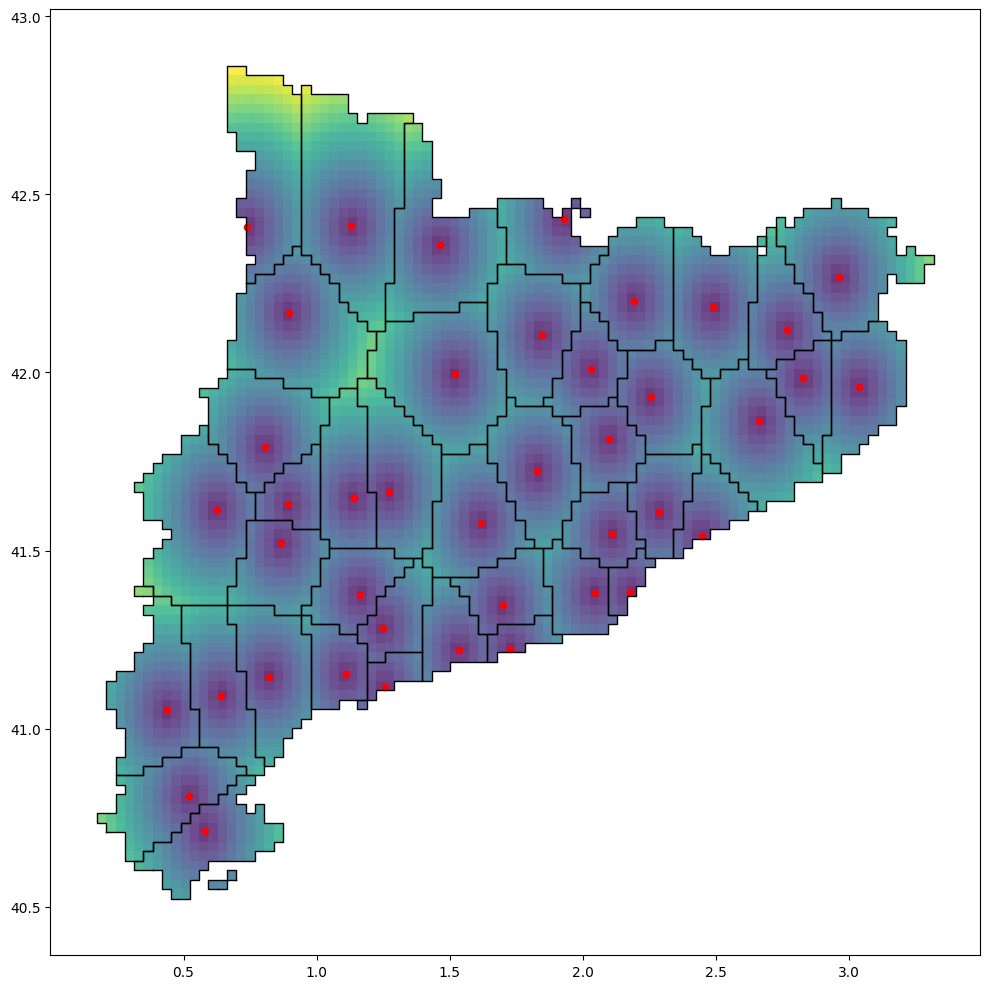

In [91]:
distance_matrix = np.zeros((ny, nx))
cell_centers_flat = cell_centers
region_indices_flat = cell_region_index.ravel()
centroids_flat = points[region_indices_flat]
distances_flat = np.linalg.norm(cell_centers_flat - centroids_flat, axis=1)
distance_matrix = distances_flat.reshape(ny, nx)

plot_voronoi_with_boundaries(distance_matrix*mask, cmap="viridis")

In [45]:
gdf = gpd.read_file("divisions-administratives-v2r2-comarques-5000-20260120.json")
df_capitals = pd.read_csv("divisions-administratives-v2r2-caps-municipi-20260120.csv", sep=";")

llista = gdf["CAPCOMAR"].tolist()
llista[39] = "Sabadell"

df = pd.DataFrame(columns=df_capitals.columns)

for i in df_capitals["Municipi"]:
    if i in llista:
        df = pd.concat([df, df_capitals.loc[df_capitals["Municipi"] == i]], ignore_index=True)
df.to_csv("capitals_comarca.csv", index=False)